In [1]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
import numpy as np

In [2]:
from constants import SENTINEL_SCENES_FOLDERPATH

In [3]:
scene_folderpaths = list(SENTINEL_SCENES_FOLDERPATH.glob("*"))
print(f"Found {len(scene_folderpaths)} scenes")

Found 9 scenes


In [71]:
@dataclass
class SentinelScene:
    bounds: rasterio.coords.BoundingBox
    name: str
    red: np.ndarray
    green: np.ndarray
    blue: np.ndarray
    nir: np.ndarray
    swir: np.ndarray
    crs: str = "EPSG:32630"

    @property
    def rgb(self) -> np.ndarray:
        rgb = np.dstack((self.red, self.green, self.blue)).astype('float32')
        return rgb 
        
    @property
    def processed_rgb(self) -> np.ndarray:
        # Normalize each band
        red = ( self.red.astype('float32') - self.red.min() ) / ( self.red.max() - self.red.min())
        green = ( self.green.astype('float32') - self.green.min() ) / ( self.green.max() - self.green.min())
        blue = ( self.blue.astype('float32') - self.blue.min() ) / ( self.blue.max() - self.blue.min())
        
        # Brighten
        gamma = 2.5
        red = np.power(red, 1/gamma)
        green = np.power(green, 1/gamma)
        blue = np.power(blue, 1/gamma)

        return np.dstack((red, green, blue))
            
    @staticmethod
    def load_tif(p: Path) -> tuple[np.ndarray, rasterio.coords.BoundingBox]:
        with rasterio.open(p) as src:
            return src.read(1), src.bounds

    @staticmethod
    def from_folderpath(p: Path) -> "SentinelScene":
        name = p.name

        # Load each .tif
        red, bounds = SentinelScene.load_tif(p / f"{p.name}_red.tif")
        green, _ = SentinelScene.load_tif(p / f"{p.name}_green.tif")
        blue, _ = SentinelScene.load_tif(p / f"{p.name}_blue.tif")
        nir, _ = SentinelScene.load_tif(p / f"{p.name}_nir.tif")
        swir, _ = SentinelScene.load_tif(p / f"{p.name}_swir22.tif")

        return SentinelScene(bounds=bounds, name=name, red=red, green=green, blue=blue, nir=nir, swir=swir)

In [74]:
s = SentinelScene.from_folderpath(scene_folderpaths[6])

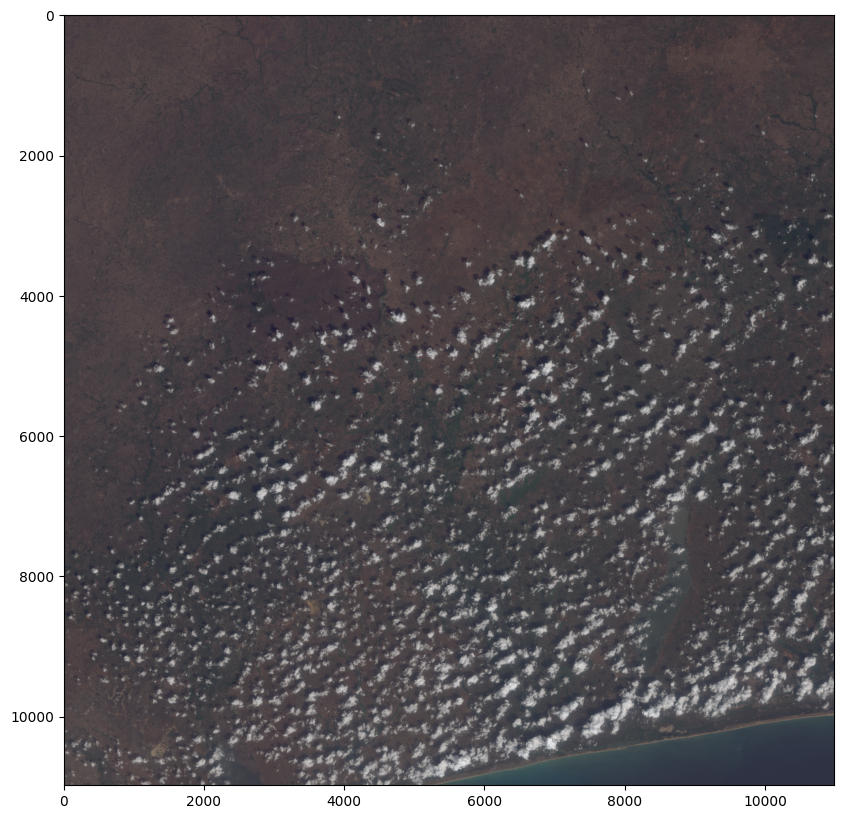

In [75]:
plt.figure(figsize=(10, 10))
plt.imshow(s.processed_rgb)